In [108]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import sympy as sym
import inspect

In [109]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x)) - 0.5

def euler_integrate(A, r_init, dt=0.01, T=100):
    N = len(r_init)
    r = np.zeros((T, N))
    r[0] = r_init
    
    for t in range(1, T):
        dr_dt = -r[t-1] + sigmoid(A @ r[t-1])
        r[t] = r[t-1] + dt * dr_dt
    
    return r

def fully_connected(N, J):
    return np.full((N, N), J / N)

def erdos_renyi(N, J, p):
    J = J / np.sqrt(p) # based on bifurcation point calculation
    k = max(1, p * N)
    A = (np.random.rand(N, N) < p).astype(float) * (J / k)
    return A

def gaussian_random(N, J):
    A = np.random.normal(0, J / np.sqrt(N), (N, N))
    np.fill_diagonal(A, 0)
    return A

def plot_results(r, network_type):
    T, N = r.shape
    mean_rate = np.mean(r, axis=1)
    variance = np.var(r, axis=1)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(r[:, :min(N, 10)])
    plt.xlabel("Time")
    plt.ylabel("Firing rate")
    plt.title(f"Individual Neuron Firing Rates ({network_type})")
    
    plt.subplot(1, 2, 2)
    plt.plot(mean_rate, label="Mean Rate")
    plt.plot(variance, label="Variance")
    plt.xlabel("Time")
    plt.ylabel("Rate / Variance")
    plt.legend()
    plt.title(f"Population Statistics ({network_type})")
    
    plt.tight_layout()
    plt.show()

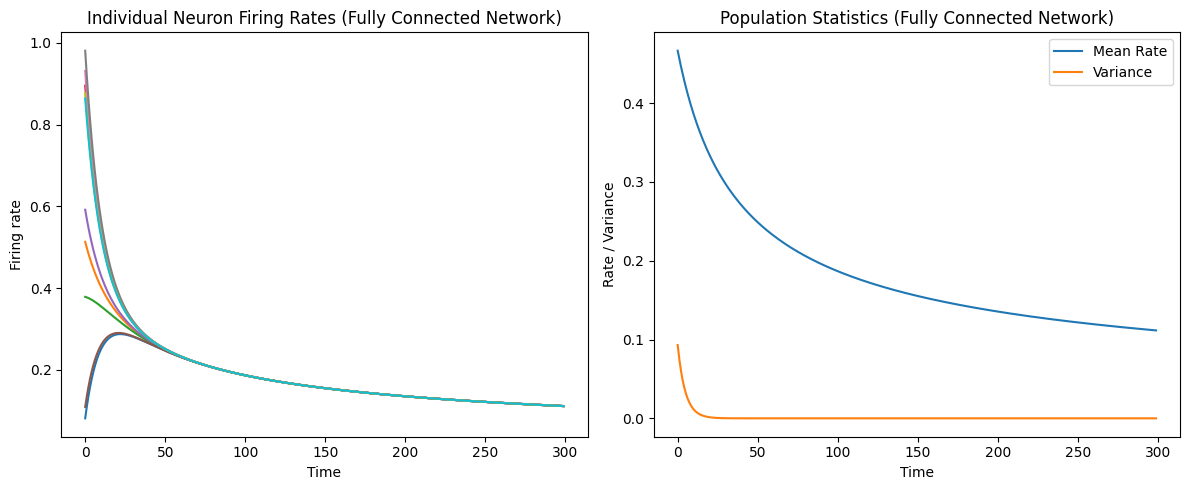

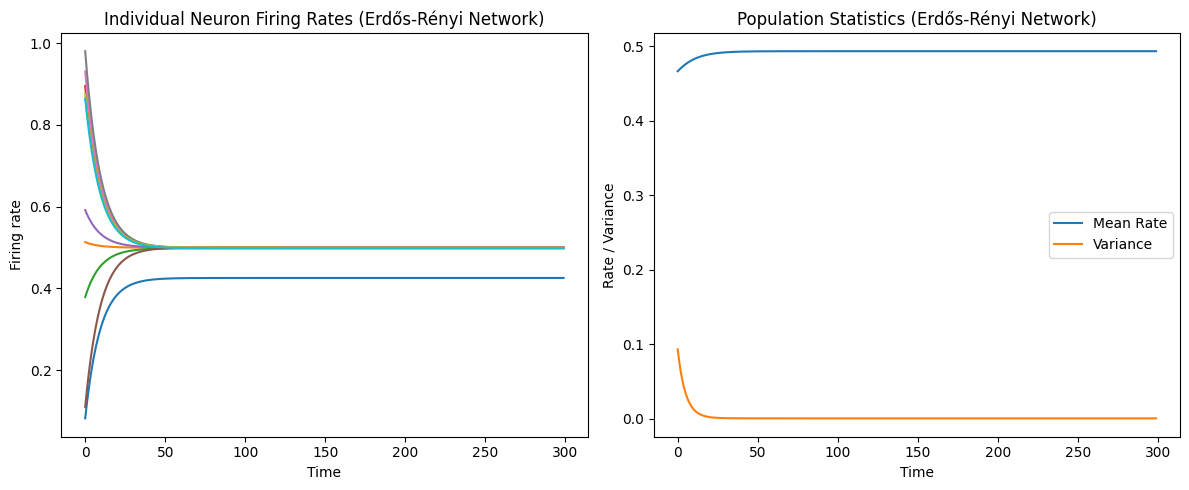

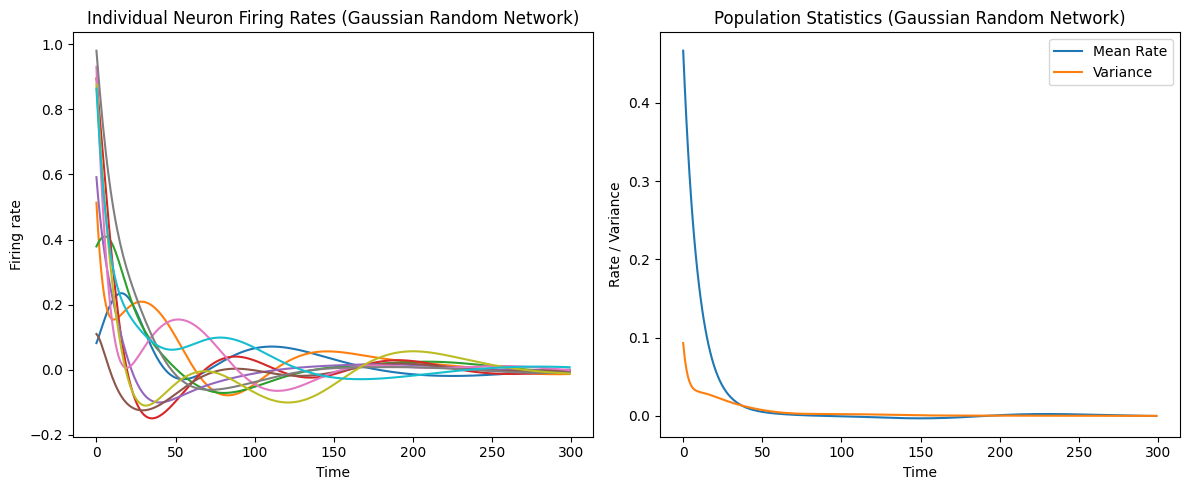

In [110]:
# parameters
N = 100 # no. of neurons
J = 4.0 # coupling strength
dt = 0.1 # time step
T = 300 # total time steps
r_init = np.random.uniform(0, 1, N) # initial firing rates

# firing rate evolution is simulated using the Euler method for each type of network

# Fully Connected Network
A_fc = fully_connected(N, J)
r_fc = euler_integrate(A_fc, r_init, dt, T)
plot_results(r_fc, "Fully Connected Network")

# Erdos-Renyi Network
p = 0.1
A_er = erdos_renyi(N, J, p)
r_er = euler_integrate(A_er, r_init, dt, T)
plot_results(r_er, "Erdős-Rényi Network")

# Gaussian Random Network
A_gr = gaussian_random(N, J)
r_gr = euler_integrate(A_gr, r_init, dt, T)
plot_results(r_gr, "Gaussian Random Network")

In [111]:
def define_symbolic_functions():
    """Define symbolic sigmoid function and calculate its derivative at zero"""
    x = sym.Symbol('x')
    sigmoid_sym = 1 / (1 + sym.exp(-x)) - 0.5
    sigmoid_prime_sym = sym.diff(sigmoid_sym, x)
    sigmoid_prime_0_sym = float(sigmoid_prime_sym.subs(x, 0))
    
    # convert symbolic functions to numeric using lambdify
    sigmoid_func = sym.lambdify(x, sigmoid_sym, "numpy")
    sigmoid_derivative_func = sym.lambdify(x, sigmoid_prime_sym, "numpy")
    
    print(f"Sigmoid derivative at x=0: {sigmoid_prime_0_sym}")
    
    return {
        'sigmoid': sigmoid_func,
        'sigmoid_derivative': sigmoid_derivative_func,
        'sigmoid_derivative_at_zero': sigmoid_prime_0_sym
    }

# get symbolic functions
sym_funcs = define_symbolic_functions()
sigmoid = sym_funcs['sigmoid']
sigmoid_derivative = sym_funcs['sigmoid_derivative']
sigmoid_prime_0_sym = sym_funcs['sigmoid_derivative_at_zero']

Sigmoid derivative at x=0: 0.25


In [112]:
def compute_jacobian(A, r):
    """Compute the Jacobian matrix at state r"""
    N = len(r)
    inputs = A @ r  # inputs to each neuron
    
    # diagonal elements (partial derivatives wrt own rate)
    diag_elements = np.full(N, -1)  # from -r_i term in the dynmaics equation
    
    # off-diagonal elements (effects from other neurons)
    sigmoid_derivatives = sigmoid_derivative(inputs)
    J_matrix = A * sigmoid_derivatives[:, np.newaxis]
    
    np.fill_diagonal(J_matrix, diag_elements)
    
    return J_matrix

def analyze_eigenvalues(jacobian):
    """Analyze eigenvalues of Jacobian matrix"""
    eigenvalues = np.linalg.eigvals(jacobian)
    
    # check stability (all eigenvalues have negative real parts?)
    is_stable = np.all(np.real(eigenvalues) < 0)
    
    # calculate spectral radius (maximum absolute eigenvalue)
    spectral_radius = np.max(np.abs(eigenvalues))
    
    return {
        'eigenvalues': eigenvalues,
        'is_stable': is_stable,
        'spectral_radius': spectral_radius,
        'max_real_part': np.max(np.real(eigenvalues))
    }

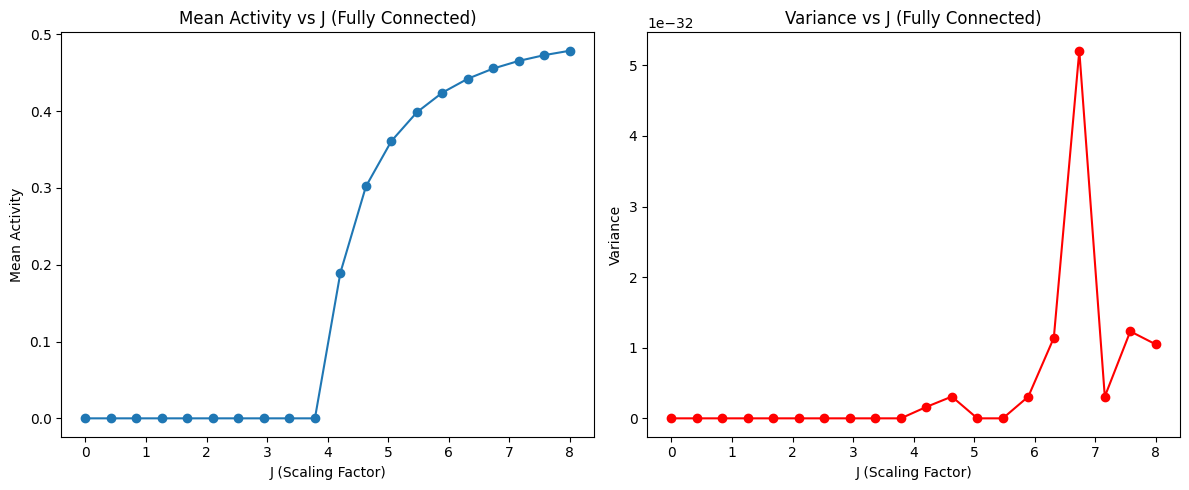

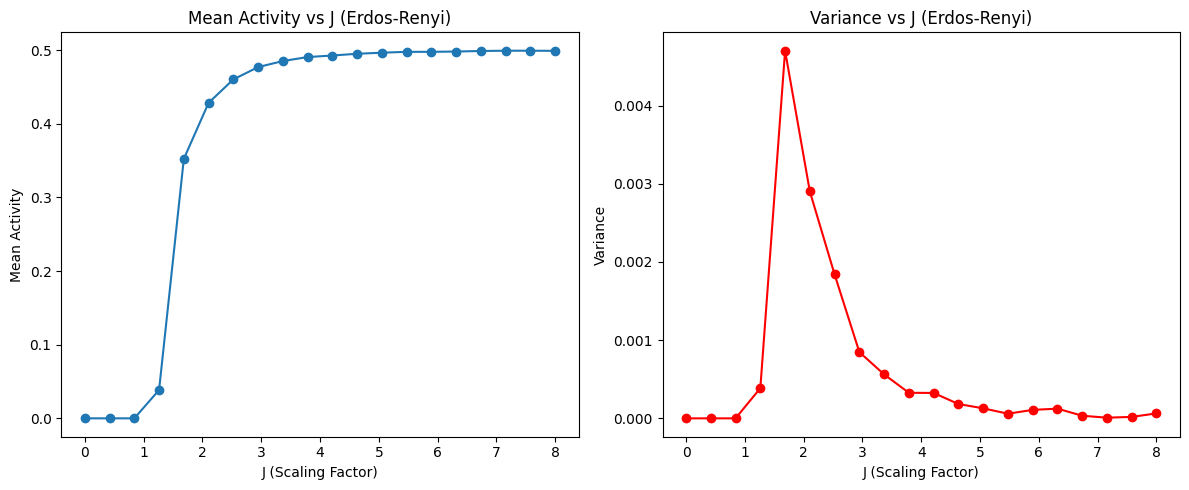

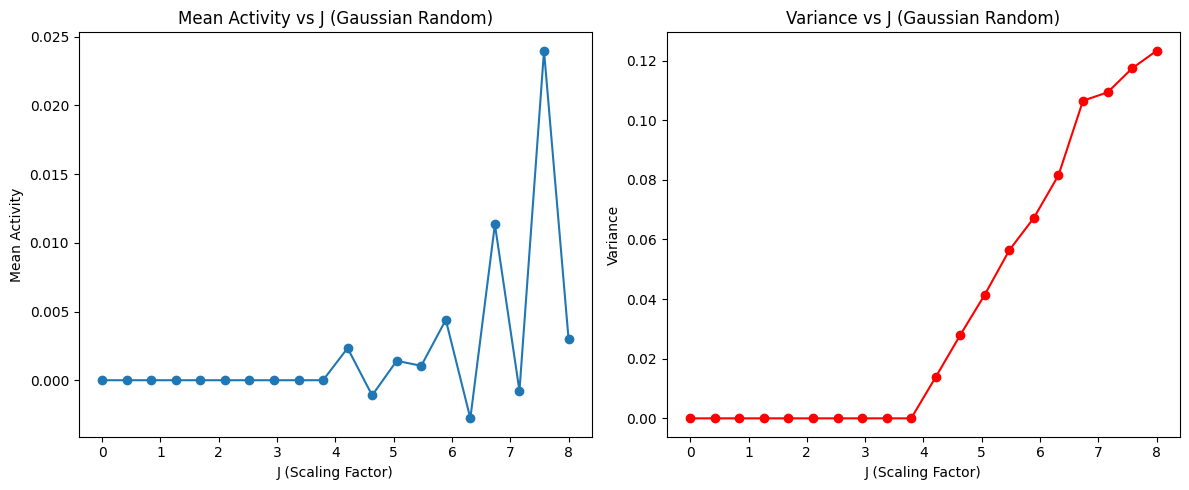

In [113]:
# Parameters
time_steps = int(T / dt)
n_trials = 10  # Number of trials for averaging
J_values = np.linspace(0, 8, 20)  # Range of J values

def euler_method(r, A, dt, J):
    inputs = np.dot(A, r)
    return r + dt * (-r + sigmoid(inputs))

def call_with_compatible_args(func, *args):
    num_params = len(inspect.signature(func).parameters)
    return func(*args[:num_params])

network_creators = {
    "Fully Connected": fully_connected,
    "Erdos-Renyi": erdos_renyi,
    "Gaussian Random": gaussian_random,
}


# Storage for results
results = {network_name: {"mean_activity": [], "var_activity": []} for network_name in network_creators.keys()}

# Iterate over network types and J values
for network_name, create_network in network_creators.items():
    for J in J_values:
        trial_means = []
        trial_vars = []

        for _ in range(n_trials):
            # Create the network adjacency matrix
            A = call_with_compatible_args(create_network, N, J, p)

            # Initialize rates
            r = np.random.uniform(0, 1, N)
            rates = np.zeros((time_steps, N))

            # Simulate dynamics
            for t in range(time_steps):
                rates[t] = r
                r = euler_method(r, A, dt, J)

            # Compute mean and variance at the final time step
            trial_means.append(np.mean(rates[-1]))
            trial_vars.append(np.var(rates[-1]))

        # Average over trials
        results[network_name]["mean_activity"].append(np.mean(trial_means))
        results[network_name]["var_activity"].append(np.mean(trial_vars))

# Plotting results
for network_name in network_creators.keys():
    mean_activity = results[network_name]["mean_activity"]
    var_activity = results[network_name]["var_activity"]

    plt.figure(figsize=(12, 5))

    # Mean activity vs J
    plt.subplot(1, 2, 1)
    plt.plot(J_values, mean_activity, marker='o')
    plt.title(f'Mean Activity vs J ({network_name})')
    plt.xlabel('J (Scaling Factor)')
    plt.ylabel('Mean Activity')

    # Variance vs J
    plt.subplot(1, 2, 2)
    plt.plot(J_values, var_activity, marker='o', color='r')
    plt.title(f'Variance vs J ({network_name})')
    plt.xlabel('J (Scaling Factor)')
    plt.ylabel('Variance')

    plt.tight_layout()
    plt.show()

In [114]:
def calculate_critical_points(print_values=False):
    """Calculate theoretical critical J values for each network type"""
    phi_prime_0 = sigmoid_prime_0_sym
    
    # fully connected network
    J_c_fully_connected = 1 / phi_prime_0
    
    # Erdős-Rényi network (for a couple of values of prob. p)
    p_values = [0.05, 0.1, 0.2, 0.5, 1.0]
    J_c_erdos_renyi = {p: 1 / (phi_prime_0 * np.sqrt(p)) for p in p_values}
    
    # Gaussian random network
    J_c_gaussian = 1 / phi_prime_0
    
    if print_values:
        print(f"Theoretical critical points:")
        print(f"- Fully connected: J_c = {J_c_fully_connected:.4f}")
        print(f"- Erdős-Rényi (p=0.1): J_c = {J_c_erdos_renyi[0.1]:.4f}")
        print(f"- Gaussian random: J_c = {J_c_gaussian:.4f}")
    
    return {
        'fully_connected': J_c_fully_connected,
        'erdos_renyi': J_c_erdos_renyi,
        'gaussian': J_c_gaussian
    }

def bifurcation_analysis(network_type, N=100, p=0.1, num_points=20, T=200, dt=0.01):
    """Perform bifurcation analysis by sweeping through J values"""
    # take theoretical critical points
    critical_points = calculate_critical_points()
    
    if network_type == 'fully_connected':
        J_critical = critical_points['fully_connected']
        J_range = np.linspace(0.5 * J_critical, 1.5 * J_critical, num_points)
        network_func = fully_connected
        network_params = {}
    elif network_type == 'erdos_renyi':
        J_critical = critical_points['erdos_renyi'][p]
        J_range = np.linspace(0.5 * J_critical, 1.5 * J_critical, num_points)
        network_func = erdos_renyi
        network_params = {'p': p}
    elif network_type == 'gaussian':
        J_critical = critical_points['gaussian']
        J_range = np.linspace(0.5 * J_critical, 1.5 * J_critical, num_points)
        network_func = gaussian_random
        network_params = {}
    else:
        raise ValueError(f"Unknown network type: {network_type}")
    
    # arrays to store results
    mean_rates = []
    variances = []
    max_eigenvalues = []
    
    for J in J_range:
        # create network with current J
        if network_type == 'erdos_renyi':
            A = network_func(N, J, **network_params)
        else:
            A = network_func(N, J)
        
        # initialise random state
        r_init = np.random.uniform(0, 1, N)
        
        # simulate dynamics
        r = euler_integrate(A, r_init, dt, T)
        
        # calculate steady-state statistics (last 20% of simulation)
        steady_state_idx = int(0.8 * T)
        steady_state = r[steady_state_idx:]
        mean_rate = np.mean(steady_state)
        variance = np.var(steady_state)
        
        # calculate Jacobian at fixed point (r=0)
        zero_state = np.zeros(N)
        jacobian = compute_jacobian(A, zero_state)
        eigenvalue_analysis = analyze_eigenvalues(jacobian)
        
        # store results
        mean_rates.append(mean_rate)
        variances.append(variance)
        max_eigenvalues.append(eigenvalue_analysis['max_real_part'])
    
    # plot results
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Mean rate and variance vs. J
    plt.subplot(1, 3, 1)
    plt.plot(J_range, mean_rates, 'b-', label='Mean Rate')
    plt.plot(J_range, variances, 'r-', label='Variance')
    plt.axvline(x=J_critical, color='k', linestyle='--', label=f'Critical J={J_critical:.2f}')
    plt.xlabel('Coupling Strength (J)')
    plt.ylabel('Statistics')
    plt.legend()
    plt.title(f'Bifurcation Analysis ({network_type})')
    
    # Plot 2: Max eigenvalue real part vs. J
    plt.subplot(1, 3, 2)
    plt.plot(J_range, max_eigenvalues, 'g-')
    plt.axhline(y=0, color='k', linestyle='--')
    plt.axvline(x=J_critical, color='k', linestyle='--')
    plt.xlabel('Coupling Strength (J)')
    plt.ylabel('Max Real Eigenvalue')
    plt.title('Stability Analysis')
    
    # Plot 3: Example trajectories
    plt.subplot(1, 3, 3)
    
    # find indices for below and above critical point
    below_idx = np.argmin(np.abs(J_range - 0.8 * J_critical))
    above_idx = np.argmin(np.abs(J_range - 1.2 * J_critical))
    
    # create networks with these J values
    if network_type == 'erdos_renyi':
        A_below = network_func(N, J_range[below_idx], **network_params)
        A_above = network_func(N, J_range[above_idx], **network_params)
    else:
        A_below = network_func(N, J_range[below_idx])
        A_above = network_func(N, J_range[above_idx])
    
    # simulate with same initial condition
    r_init = np.random.uniform(0, 1, N)
    r_below = euler_integrate(A_below, r_init, dt, T)
    r_above = euler_integrate(A_above, r_init, dt, T)
    
    # plot a few neurons
    for i in range(5):
        plt.plot(r_below[:, i], 'b-', alpha=0.5)
        plt.plot(r_above[:, i], 'r-', alpha=0.5)
    
    plt.xlabel('Time')
    plt.ylabel('Rate')
    plt.title(f'J={J_range[below_idx]:.2f} (blue) vs J={J_range[above_idx]:.2f} (red)')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'J_range': J_range,
        'mean_rates': mean_rates,
        'variances': variances,
        'max_eigenvalues': max_eigenvalues,
        'J_critical': J_critical
    }

def plot_eigenvalue_distribution(network_type, N=100, p=0.1, below_critical=0.8, above_critical=1.2):
    """Plot eigenvalue distribution in complex plane for stable and chaotic regimes"""
    # take critical points
    critical_points = calculate_critical_points()

    if network_type == 'fully_connected':
        J_critical = critical_points['fully_connected']
        network_func = fully_connected
        network_params = {}
        circle_radius = 1.0
        x_lim = (-2.5, 0.5)
        y_lim_stable = (-2.5, 2.5)
        y_lim_chaotic = (-2.5, 2.5)
    elif network_type == 'erdos_renyi':
        J_critical = critical_points['erdos_renyi'][p]
        network_func = erdos_renyi
        network_params = {'p': p}
        circle_radius = 1.0/np.sqrt(p)
        x_lim = (-3.5-circle_radius, 15.0)
        y_lim_stable = (-circle_radius - 3.0, circle_radius + 3.0)
        y_lim_chaotic = (-circle_radius - 3.0, circle_radius + 3.0)
    elif network_type == 'gaussian':
        J_critical = critical_points['gaussian']
        network_func = gaussian_random
        network_params = {}
        circle_radius = 1.0
        x_lim = (-2.5, 0.5)
        y_lim_stable = (-2.5, 2.5)
        y_lim_chaotic = (-2.5, 2.5)
    
    # J values below and above critical point
    J_below = below_critical * J_critical
    J_above = above_critical * J_critical
    
    # create networks
    if network_type == 'erdos_renyi':
        A_below = network_func(N, J_below, **network_params)
        A_above = network_func(N, J_above, **network_params)
    else:
        A_below = network_func(N, J_below)
        A_above = network_func(N, J_above)
    
    # initial state (fixed point at r=0)
    r_zero = np.zeros(N)
    
    # compute Jacobians
    J_matrix_below = compute_jacobian(A_below, r_zero)
    J_matrix_above = compute_jacobian(A_above, r_zero)
    
    # compute eigenvalues
    eigenvalues_below = np.linalg.eigvals(J_matrix_below)
    eigenvalues_above = np.linalg.eigvals(J_matrix_above)
    
    # simulate dynamics for visualisation
    r_init = np.random.uniform(0, 1, N)
    T = 200
    dt = 0.1
    
    r_below = euler_integrate(A_below, r_init, dt, T)
    r_above = euler_integrate(A_above, r_init, dt, T)
    
    # plot eigenvalues and dynamics
    plt.figure(figsize=(12, 5))
    
    # Panel A: Eigenvalue distribution for stable regime
    plt.subplot(1, 4, 1)
    plt.scatter(np.real(eigenvalues_below), np.imag(eigenvalues_below), alpha=0.6, c='blue')
    plt.axvline(x=0, color='k', linestyle='--')
    plt.axhline(y=0, color='k', linestyle='--')
    
    # circle with network-dependent radius centered at -1
    theta = np.linspace(0, 2*np.pi, 100)
    x = -1 + circle_radius * np.cos(theta)
    y = circle_radius * np.sin(theta)
    plt.plot(x, y, 'k--', alpha=0.3)
    
    # network-specific axis limits
    plt.xlim(x_lim)
    plt.ylim(y_lim_stable)
    plt.xlabel('Real(λ)')
    plt.ylabel('Imaginary(λ)')
    plt.title(f'Stable Regime (J={J_below:.2f})')
    
    # Panel B: Dynamics for stable regime
    plt.subplot(1, 4, 2)
    for i in range(min(10, N)):
        plt.plot(r_below[:, i])
    plt.xlabel('Time')
    plt.ylabel('Neural Activity')
    plt.title('Stable Dynamics')
    
    # Panel C: Eigenvalue distribution for chaotic regime
    plt.subplot(1, 4, 3)
    plt.scatter(np.real(eigenvalues_above), np.imag(eigenvalues_above), alpha=0.6, c='red')
    plt.axvline(x=0, color='k', linestyle='--')
    plt.axhline(y=0, color='k', linestyle='--')
    
    plt.plot(x, y, 'k--', alpha=0.3)
    
    plt.xlim(x_lim)
    plt.ylim(y_lim_chaotic)
    plt.xlabel('Real(λ)')
    plt.ylabel('Imaginary(λ)')
    plt.title(f'Chaotic Regime (J={J_above:.2f})')
    
    # Panel D: Dynamics for chaotic regime
    plt.subplot(1, 4, 4)
    for i in range(min(10, N)):
        plt.plot(r_above[:, i])
    plt.xlabel('Time')
    plt.ylabel('Neural Activity')
    plt.title('Chaotic Dynamics')
    
    plt.tight_layout()
    plt.suptitle(f'Eigenvalue Analysis for {network_type.capitalize()} Network', y=1.05)
    plt.show()
    
    return {
        'eigenvalues_stable': eigenvalues_below,
        'eigenvalues_chaotic': eigenvalues_above,
        'dynamics_stable': r_below,
        'dynamics_chaotic': r_above
    }

In [115]:
def run_full_analysis(N=100, dt=0.1, T=300, p=0.1):
    """Run complete analysis for all network types"""
    # take critical points
    critical_points = calculate_critical_points(print_values=True)
    
    # set critical J values for each network
    J_fc = critical_points['fully_connected']
    J_er = critical_points['erdos_renyi'][p]
    J_gr = critical_points['gaussian']
    
    # initial conditions
    r_init = np.random.uniform(0, 1, N)
    
    print("\nRunning bifurcation analysis...")
    # run bifurcation analysis for each network type
    results_fc = bifurcation_analysis('fully_connected', N=N, T=T, dt=dt)
    results_er = bifurcation_analysis('erdos_renyi', N=N, p=p, T=T, dt=dt)
    results_gr = bifurcation_analysis('gaussian', N=N, T=T, dt=dt)
    
    print("\nAnalyzing eigenvalue distributions...")
    # plot eigenvalue distributions and dynamics
    eigen_fc = plot_eigenvalue_distribution('fully_connected', N=N, p=p)
    eigen_er = plot_eigenvalue_distribution('erdos_renyi', N=N, p=p)
    eigen_gr = plot_eigenvalue_distribution('gaussian', N=N, p=p)
    
    print("\nRunning simulations at critical points...")
    # Fully Connected Network at critical point
    A_fc = fully_connected(N, J_fc)
    r_fc = euler_integrate(A_fc, r_init, dt, T)
    plot_results(r_fc, f"Fully Connected Network (J={J_fc:.2f}, critical)")
    
    # Erdos-Renyi Network at critical point
    A_er = erdos_renyi(N, J_er, p)
    r_er = euler_integrate(A_er, r_init, dt, T)
    plot_results(r_er, f"Erdős-Rényi Network (J={J_er:.2f}, critical)")
    
    # Gaussian Random Network at critical point
    A_gr = gaussian_random(N, J_gr)
    r_gr = euler_integrate(A_gr, r_init, dt, T)
    plot_results(r_gr, f"Gaussian Random Network (J={J_gr:.2f}, critical)")

Theoretical critical points:
- Fully connected: J_c = 4.0000
- Erdős-Rényi (p=0.1): J_c = 12.6491
- Gaussian random: J_c = 4.0000

Running bifurcation analysis...


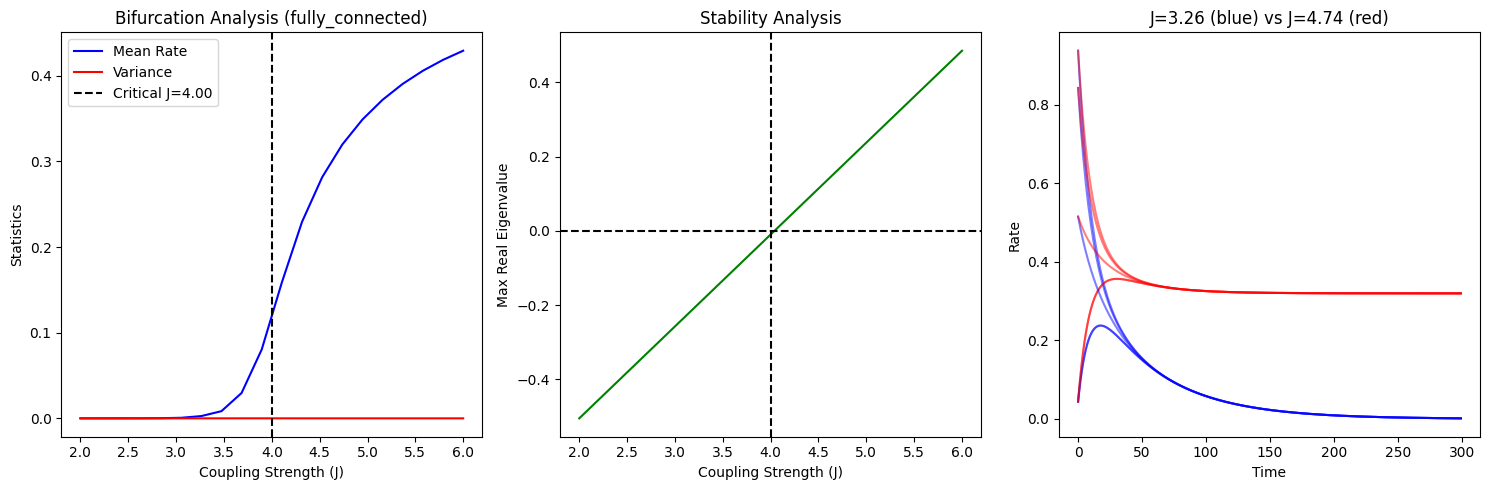

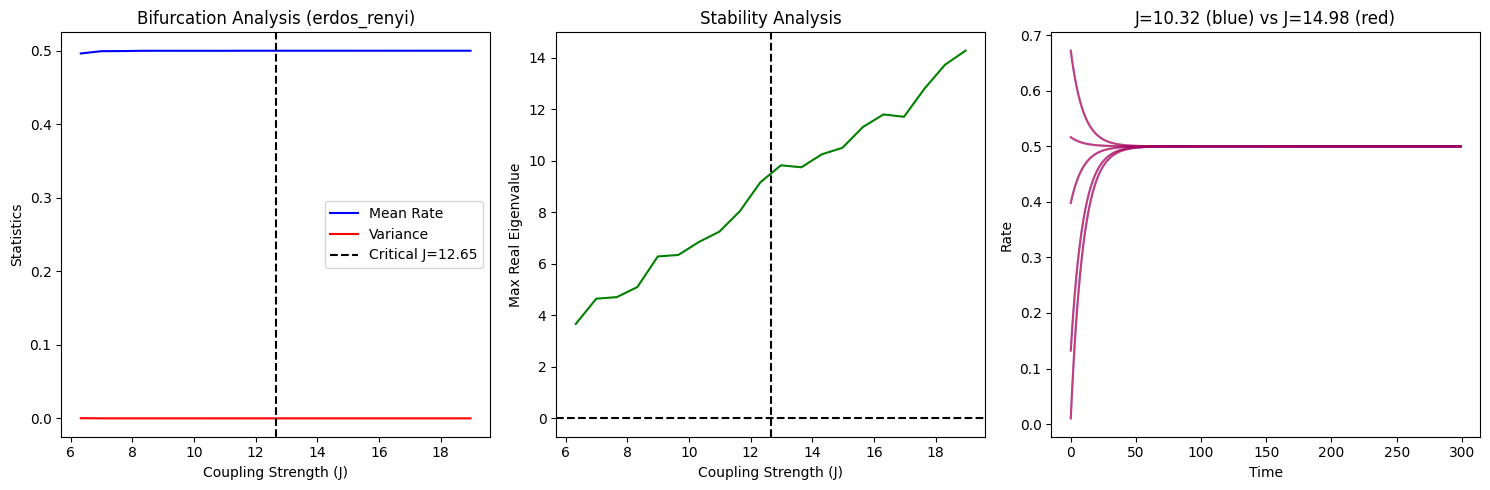

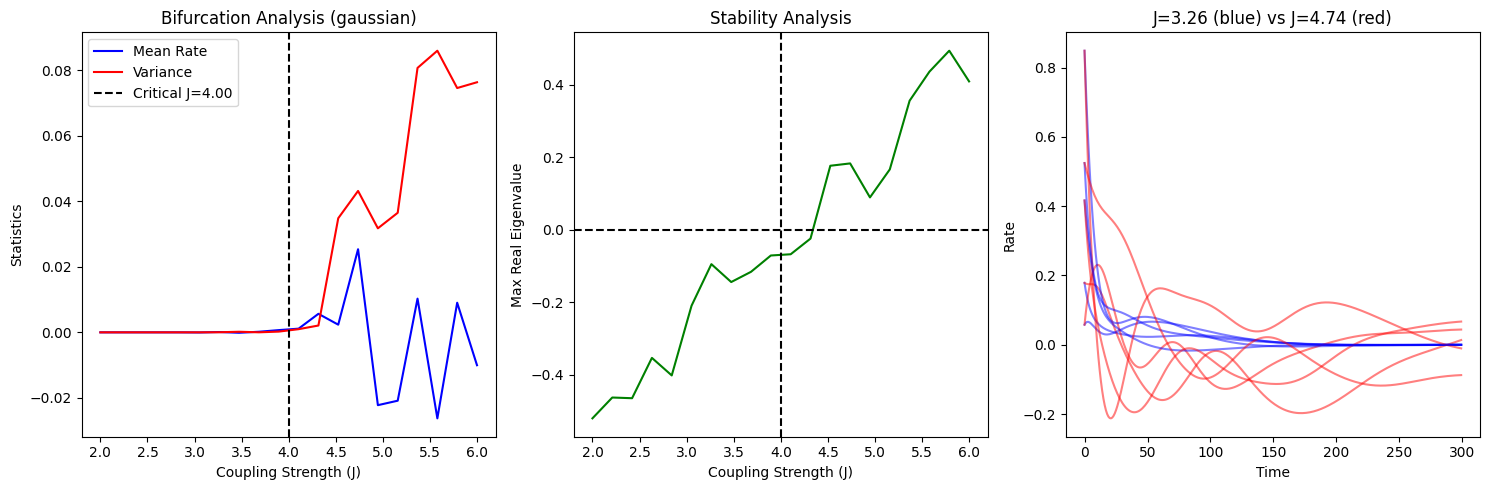


Analyzing eigenvalue distributions...


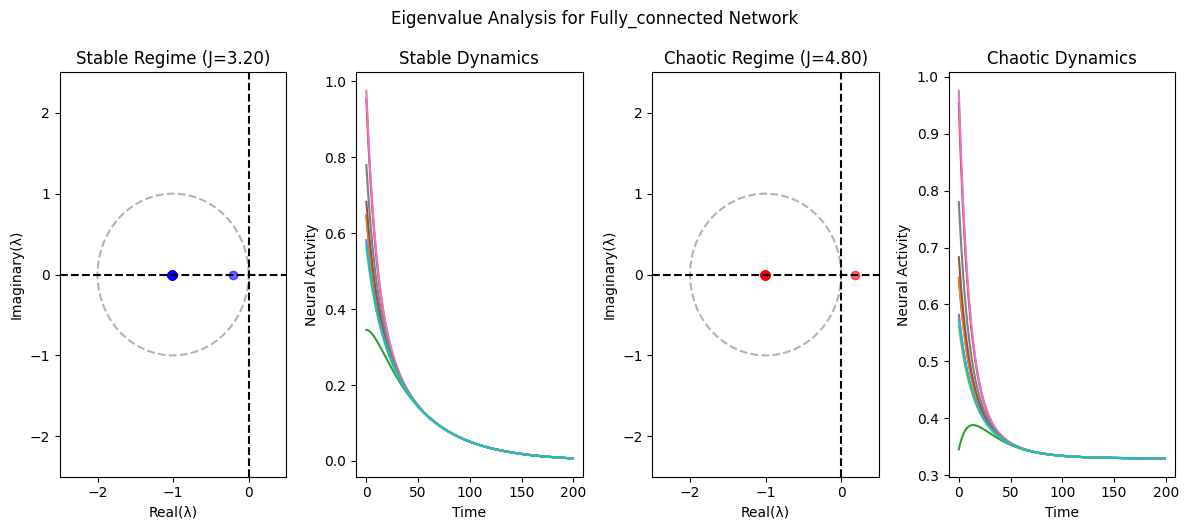

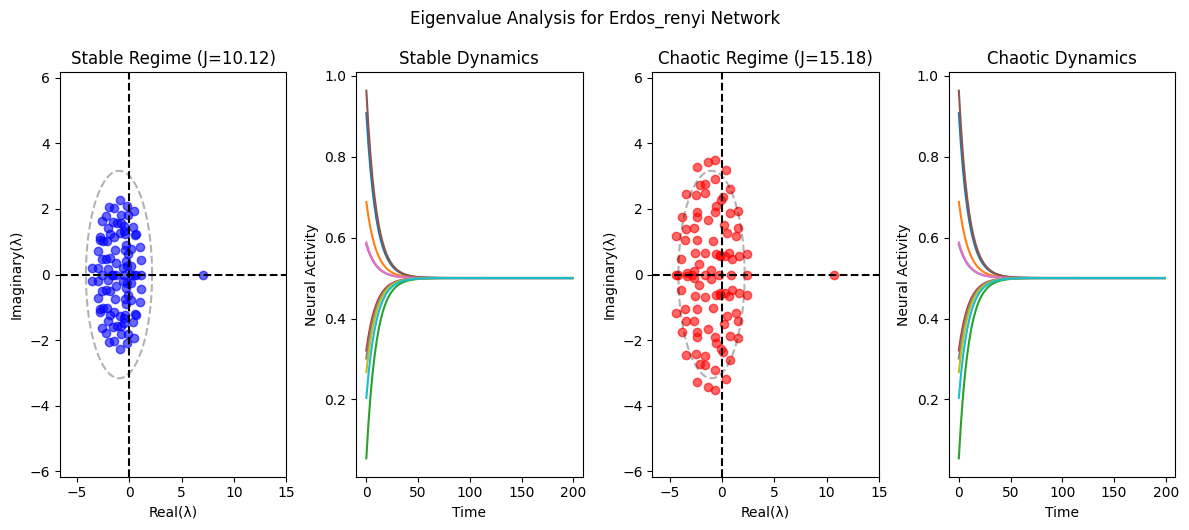

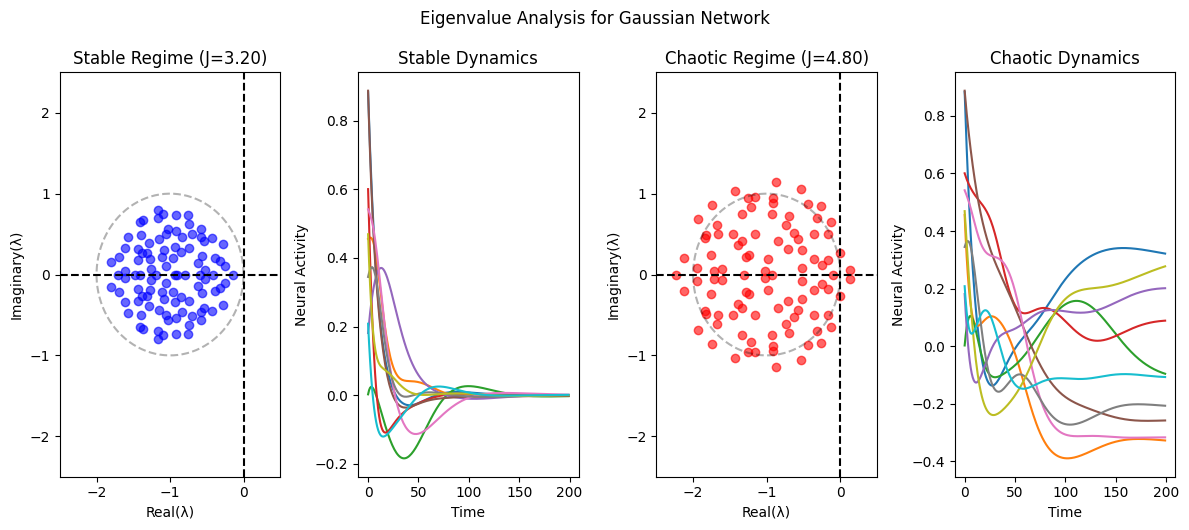


Running simulations at critical points...


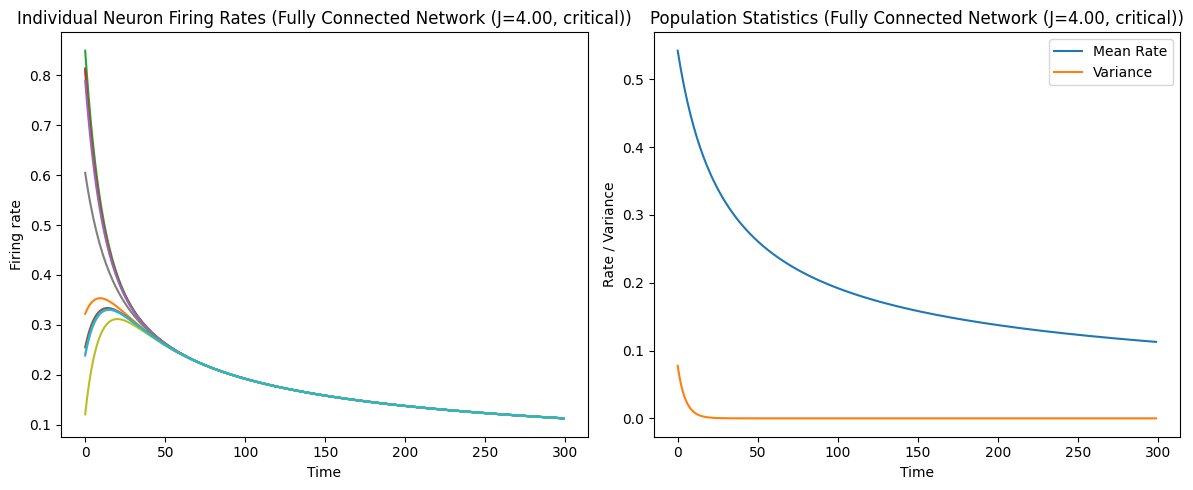

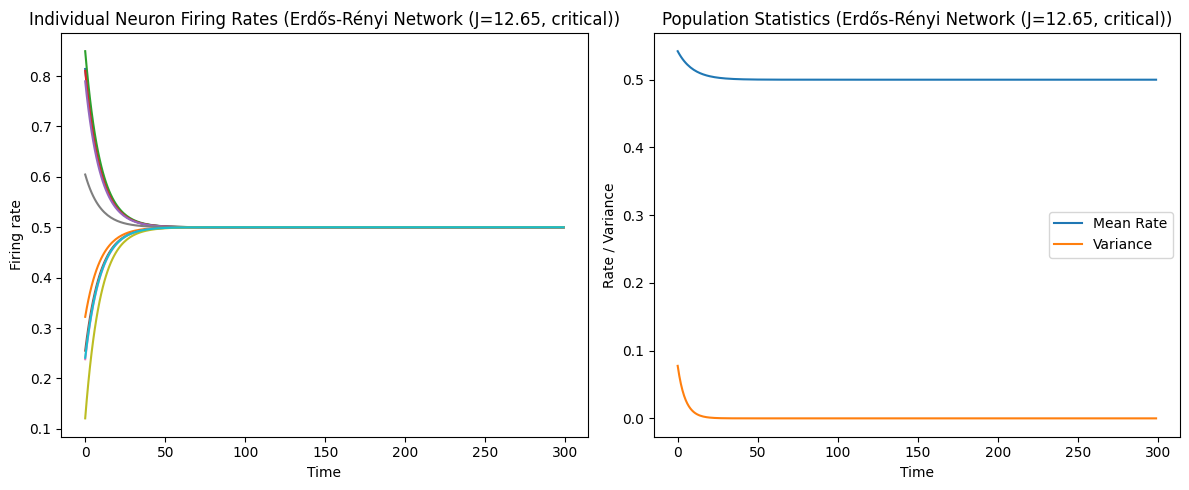

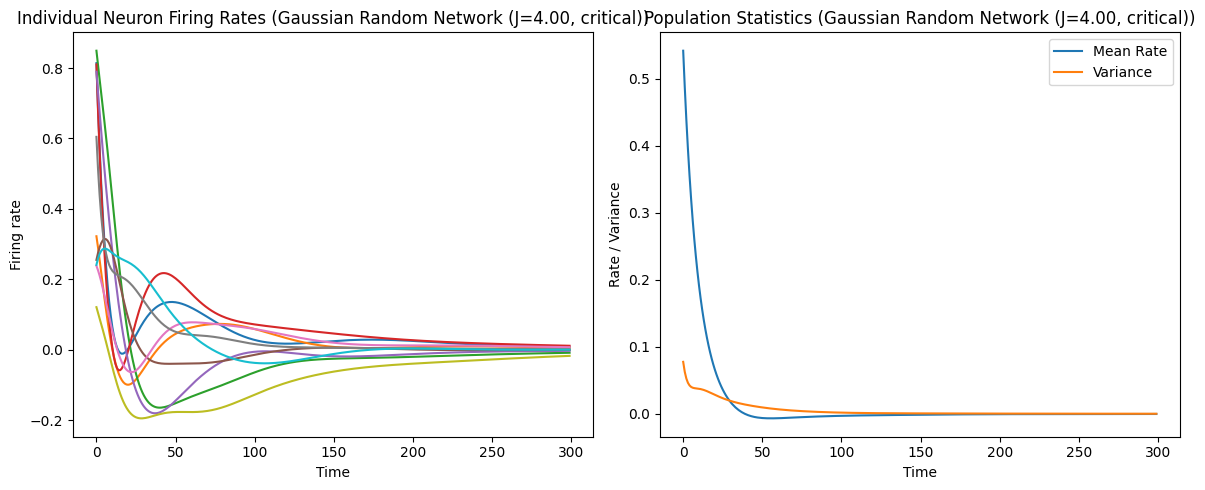

In [116]:
run_full_analysis(N, dt, T, p)